# Create WecOptTool Model for the Marson WEC concept

In [70]:
import numpy as np
import jax.numpy as jnp
import capytaine as cpt
from capytaine.io.meshio import load_from_meshio
import matplotlib.pyplot as plt
from scipy.optimize import brute
import pygmsh
from scipy.linalg import block_diag
import xarray as xr
import jax

import wecopttool as wot

## set colorblind-friendly colormap for plots
plt.style.use('tableau-colorblind10')

import logging
logging.getLogger().setLevel(logging.INFO)

### Waves and Frequency array

In [71]:
wavefreq = 1/8 # Hz
f1 = wavefreq
nfreq = 10

freq = wot.frequency(f1, nfreq, False) # False -> no zero frequency

amplitude = 0.5 # m
phase = 30 # degrees
wavedir = 0 # degrees

waves = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

#### WEC geometry mesh
Now we will create a surface mesh for the WEC hull and store it using the `FloatingBody` object from Capytaine.

INFO:capytaine.io.meshio:Stored 340 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_63"), lid_mesh=None, dofs={}, center_of_mass=[ 0.    0.   -0.46], name="platform").
INFO:capytaine.bodies.bodies:Clipping platform with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_63 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.    0.   -0.46]
INFO:capytaine.io.meshio:Stored 352 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_64"), lid_mesh=None, dofs={}, center_of_mass=[-0.695  0.    -0.18 ], name="flap1").
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., 

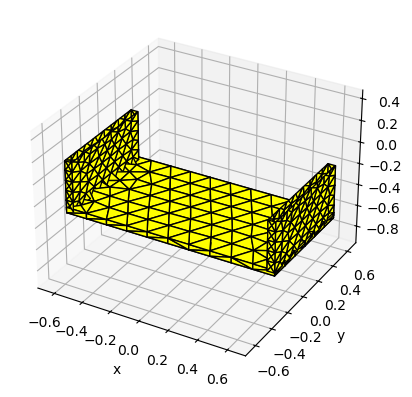

In [72]:
# platform is a rectangle with cg at -0.46 and 1.44 m long, 0.76 m wide
platformLength = 1.44 
platformWidth = 0.76
platformHeight = 0.05
platformCG = [0, 0, -0.46]

flapThickness = 0.05
flapWidth = platformWidth
flapHeight = 0.56
flap1CG = [-platformLength/2+flapThickness/2, 0, platformCG[2]+0.56/2] # from water surface/origin
flap2CG = [platformLength/2-flapThickness/2, 0, platformCG[2]+0.56/2] # from water surface/origin

with pygmsh.geo.Geometry() as geom:
    platform = geom.add_box(-platformLength/2, platformLength/2, -platformWidth/2, platformWidth/2, 
                       platformCG[2] - platformHeight/2, platformCG[2] + platformHeight/2, mesh_size = 0.15)
    platformMesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap1 = geom.add_box(-platformLength/2, -platformLength/2 + flapThickness, -flapWidth/2, flapWidth/2, 
                       platformCG[2], platformCG[2] + flapHeight, mesh_size = 0.1)
    flap1Mesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap2 = geom.add_box(platformLength/2 - flapThickness, platformLength/2, -flapWidth/2, flapWidth/2, 
                       platformCG[2], platformCG[2] + flapHeight, mesh_size = 0.1)
    flap2Mesh = geom.generate_mesh()

# define the floating body
platform = cpt.FloatingBody(mesh=platformMesh, name=f'platform', center_of_mass=platformCG)
platform = platform.immersed_part()
platform.rotation_center = platform.center_of_mass
platform.add_translation_dof(name='Surge')
platform.add_translation_dof(name='Heave')
platform.add_rotation_dof(name='Pitch')
platform.inertia_matrix = platform.compute_rigid_body_inertia()
platform.hydrostatic_stiffness = platform.compute_hydrostatic_stiffness()

# define the floating body
flap1 = cpt.FloatingBody(mesh=flap1Mesh, name=f'flap1', center_of_mass=flap1CG)
flap1.rotation_center = flap1CG # define rotation about cg and M4E will handle transformaiton
flap1.add_translation_dof(name='Surge')
flap1.add_translation_dof(name='Heave')
flap1.add_rotation_dof(name='Pitch')
flap1.mass = 0.2*1000*flapWidth*flapThickness*flapHeight
flap1.inertia_matrix = flap1.compute_rigid_body_inertia()
flap1 = flap1.immersed_part()
flap1.hydrostatic_stiffness = flap1.compute_hydrostatic_stiffness()

# define the floating body
flap2 = cpt.FloatingBody(mesh=flap2Mesh, name=f'flap2', center_of_mass=flap2CG)
flap2.rotation_center = flap2CG
flap2.add_translation_dof(name='Surge')
flap2.add_translation_dof(name='Heave')
flap2.add_rotation_dof(name='Pitch')
flap2.mass = 0.2*1000*flapWidth*flapThickness*flapHeight
flap2.inertia_matrix = flap2.compute_rigid_body_inertia()
flap2 = flap2.immersed_part()
flap2.hydrostatic_stiffness = flap2.compute_hydrostatic_stiffness()

all_bodies = platform + flap1 + flap2

#all_bodies.show()
all_bodies.show_matplotlib()


In [73]:
# check that mass and inertia matrices are the same between wecopttool and wec-sim

# masses from WEC-Sim
platform_mass_ws = 54.72
platform_inertia_ws = [0, 9.46701600000000, 0]
flap1_mass_ws = 3.496
flap1_inertia_ws = [0,0.112110133333333,0]
flap2_mass_ws = 3.496
flap2_inertia_ws = [0,0.112110133333333,0]

platform_hs_ws = np.array([
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0],
    [0, 0, -2.17400731563297e-12, 2.54766482300738e-14, -8.49221607669128e-14, 0],
    [0, 0, 2.54766482300738e-14, 3.11551809917935e-09, -3.70458064967523e-10, 0],
    [0, 0, -8.49221607669128e-14, -3.70458064967523e-10, 3.06239079540357e-09, 0],
    [0, 0, 0, 0, 0, 0]
])

flap1_hs_ws = np.array([
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0],
    [0, 0, 372.052624390245, -1.04397102518532e-14, -1.88206421307489e-14, 0],
    [0, 0, -1.04397102518532e-14, 9.01929053398376, 0.0218179008127874, 0],
    [0, 0, -1.88206421307489e-14, 0.0218179008127874, -8.53137337317073, 0],
    [0, 0, 0, 0, 0, 0]
])


flap2_hs_ws = np.array([
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0],
    [0, 0, 372.052624390244, 3.43971765139529e-14, 2.48366000405869e-14, 0],
    [0, 0, 3.43971765139529e-14, 9.01929053398379, 0.0218179008127883, 0],
    [0, 0, 2.48366000405869e-14, 0.0218179008127883, -8.53137337317071, 0],
    [0, 0, 0, 0, 0, 0]
])

print(platform.inertia_matrix)
print(flap1.inertia_matrix)
print(flap2.inertia_matrix)

print(platform.hydrostatic_stiffness)
print(flap1.hydrostatic_stiffness)
print(flap2.hydrostatic_stiffness)

<xarray.DataArray 'inertia_matrix' (influenced_dof: 3, radiating_dof: 3)> Size: 72B
array([[54.72      ,  0.        ,  0.        ],
       [ 0.        , 54.72      , -0.        ],
       [ 0.        , -0.        ,  9.42658695]])
Coordinates:
  * influenced_dof  (influenced_dof) <U5 60B 'Surge' 'Heave' 'Pitch'
  * radiating_dof   (radiating_dof) <U5 60B 'Surge' 'Heave' 'Pitch'
<xarray.DataArray 'inertia_matrix' (influenced_dof: 3, radiating_dof: 3)> Size: 72B
array([[ 4.256    ,  0.       ,  0.       ],
       [ 0.       ,  4.256    , -0.       ],
       [ 0.       , -0.       ,  0.1110765]])
Coordinates:
  * influenced_dof  (influenced_dof) <U5 60B 'Surge' 'Heave' 'Pitch'
  * radiating_dof   (radiating_dof) <U5 60B 'Surge' 'Heave' 'Pitch'
<xarray.DataArray 'inertia_matrix' (influenced_dof: 3, radiating_dof: 3)> Size: 72B
array([[ 4.256     ,  0.        ,  0.        ],
       [ 0.        ,  4.256     , -0.        ],
       [ 0.        , -0.        ,  0.11107649]])
Coordinates:
  * influ

In [74]:
bem_data = wot.run_bem(all_bodies, freq, wave_dirs=0)

INFO:capytaine.green_functions.delhommeau:Loading tabulation from C:\Users\jtgrasb\AppData\Local\capytaine\Cache\2.3.1\tabulation_float64_scaled_nemoh3_676_100.0_372_-251.0_1001.npz


[09:57:37] WARNING  Using the geometric centroid as the center of gravity (COG).

           WARNING  Using the center of gravity (COG) as the rotation center for hydrostatics. Note that the       
                    hydrostatics do not use the axes defined by the FloatingBody degrees of freedom, and the       
                    rotation center should be set manually when using Capytaine to calculate hydrostatics about an 
                    axis other than the COG.

INFO:capytaine.bodies.bodies:Clipping copy_of_platform+flap1+flap2 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_63 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_64 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_70 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.


Output()

...

INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_platform+flap1+flap2_immersed"), omega=7.069, water_depth=inf, radiating_dof='platform__Surge', rho=1025.0).


INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_platform+flap1+flap2_immersed"), omega=7.069, water_depth=inf, radiating_dof='platform__Heave', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_platform+flap1+flap2_immersed"), omega=7.069, water_depth=inf, radiating_dof='platform__Pitch', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_platform+flap1+flap2_immersed"), omega=7.069, water_depth=inf, radiating_dof='flap1__Surge', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_platform+flap1+flap2_immersed"), omega=7.069, water_depth=inf, radiating_dof='flap1__Heave', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_platform+flap1+flap2_immersed"), omega=7.069, water_depth=inf, radiating_dof='flap1__Pitch', rho=1025.0).
INFO:capytaine.bem.solver:Solve Ra

INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_platform+flap1+flap2_immersed"), omega=7.854, water_depth=inf, radiating_dof='platform__Surge', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_platform+flap1+flap2_immersed"), omega=7.854, water_depth=inf, radiating_dof='platform__Heave', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_platform+flap1+flap2_immersed"), omega=7.854, water_depth=inf, radiating_dof='platform__Pitch', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_platform+flap1+flap2_immersed"), omega=7.854, water_depth=inf, radiating_dof='flap1__Surge', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_platform+flap1+flap2_immersed"), omega=7.854, water_depth=inf, radiating_dof='flap1__Heave', rho=1025.0).
INFO:capytaine.bem.solver:Solve

INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_platform+flap1+flap2_immersed"), omega=7.854, water_depth=inf, radiating_dof='flap2__Heave', rho=1025.0).
INFO:capytaine.bem.solver:Solve RadiationProblem(body=FloatingBody(..., name="copy_of_platform+flap1+flap2_immersed"), omega=7.854, water_depth=inf, radiating_dof='flap2__Pitch', rho=1025.0).


INFO:capytaine.bem.solver:Solver timer summary:
                  total  nb_calls   mean
task                                    
Solve total       7.086       100  0.071
  Green function  2.132       100  0.021
  Linear solver   3.983       100  0.040


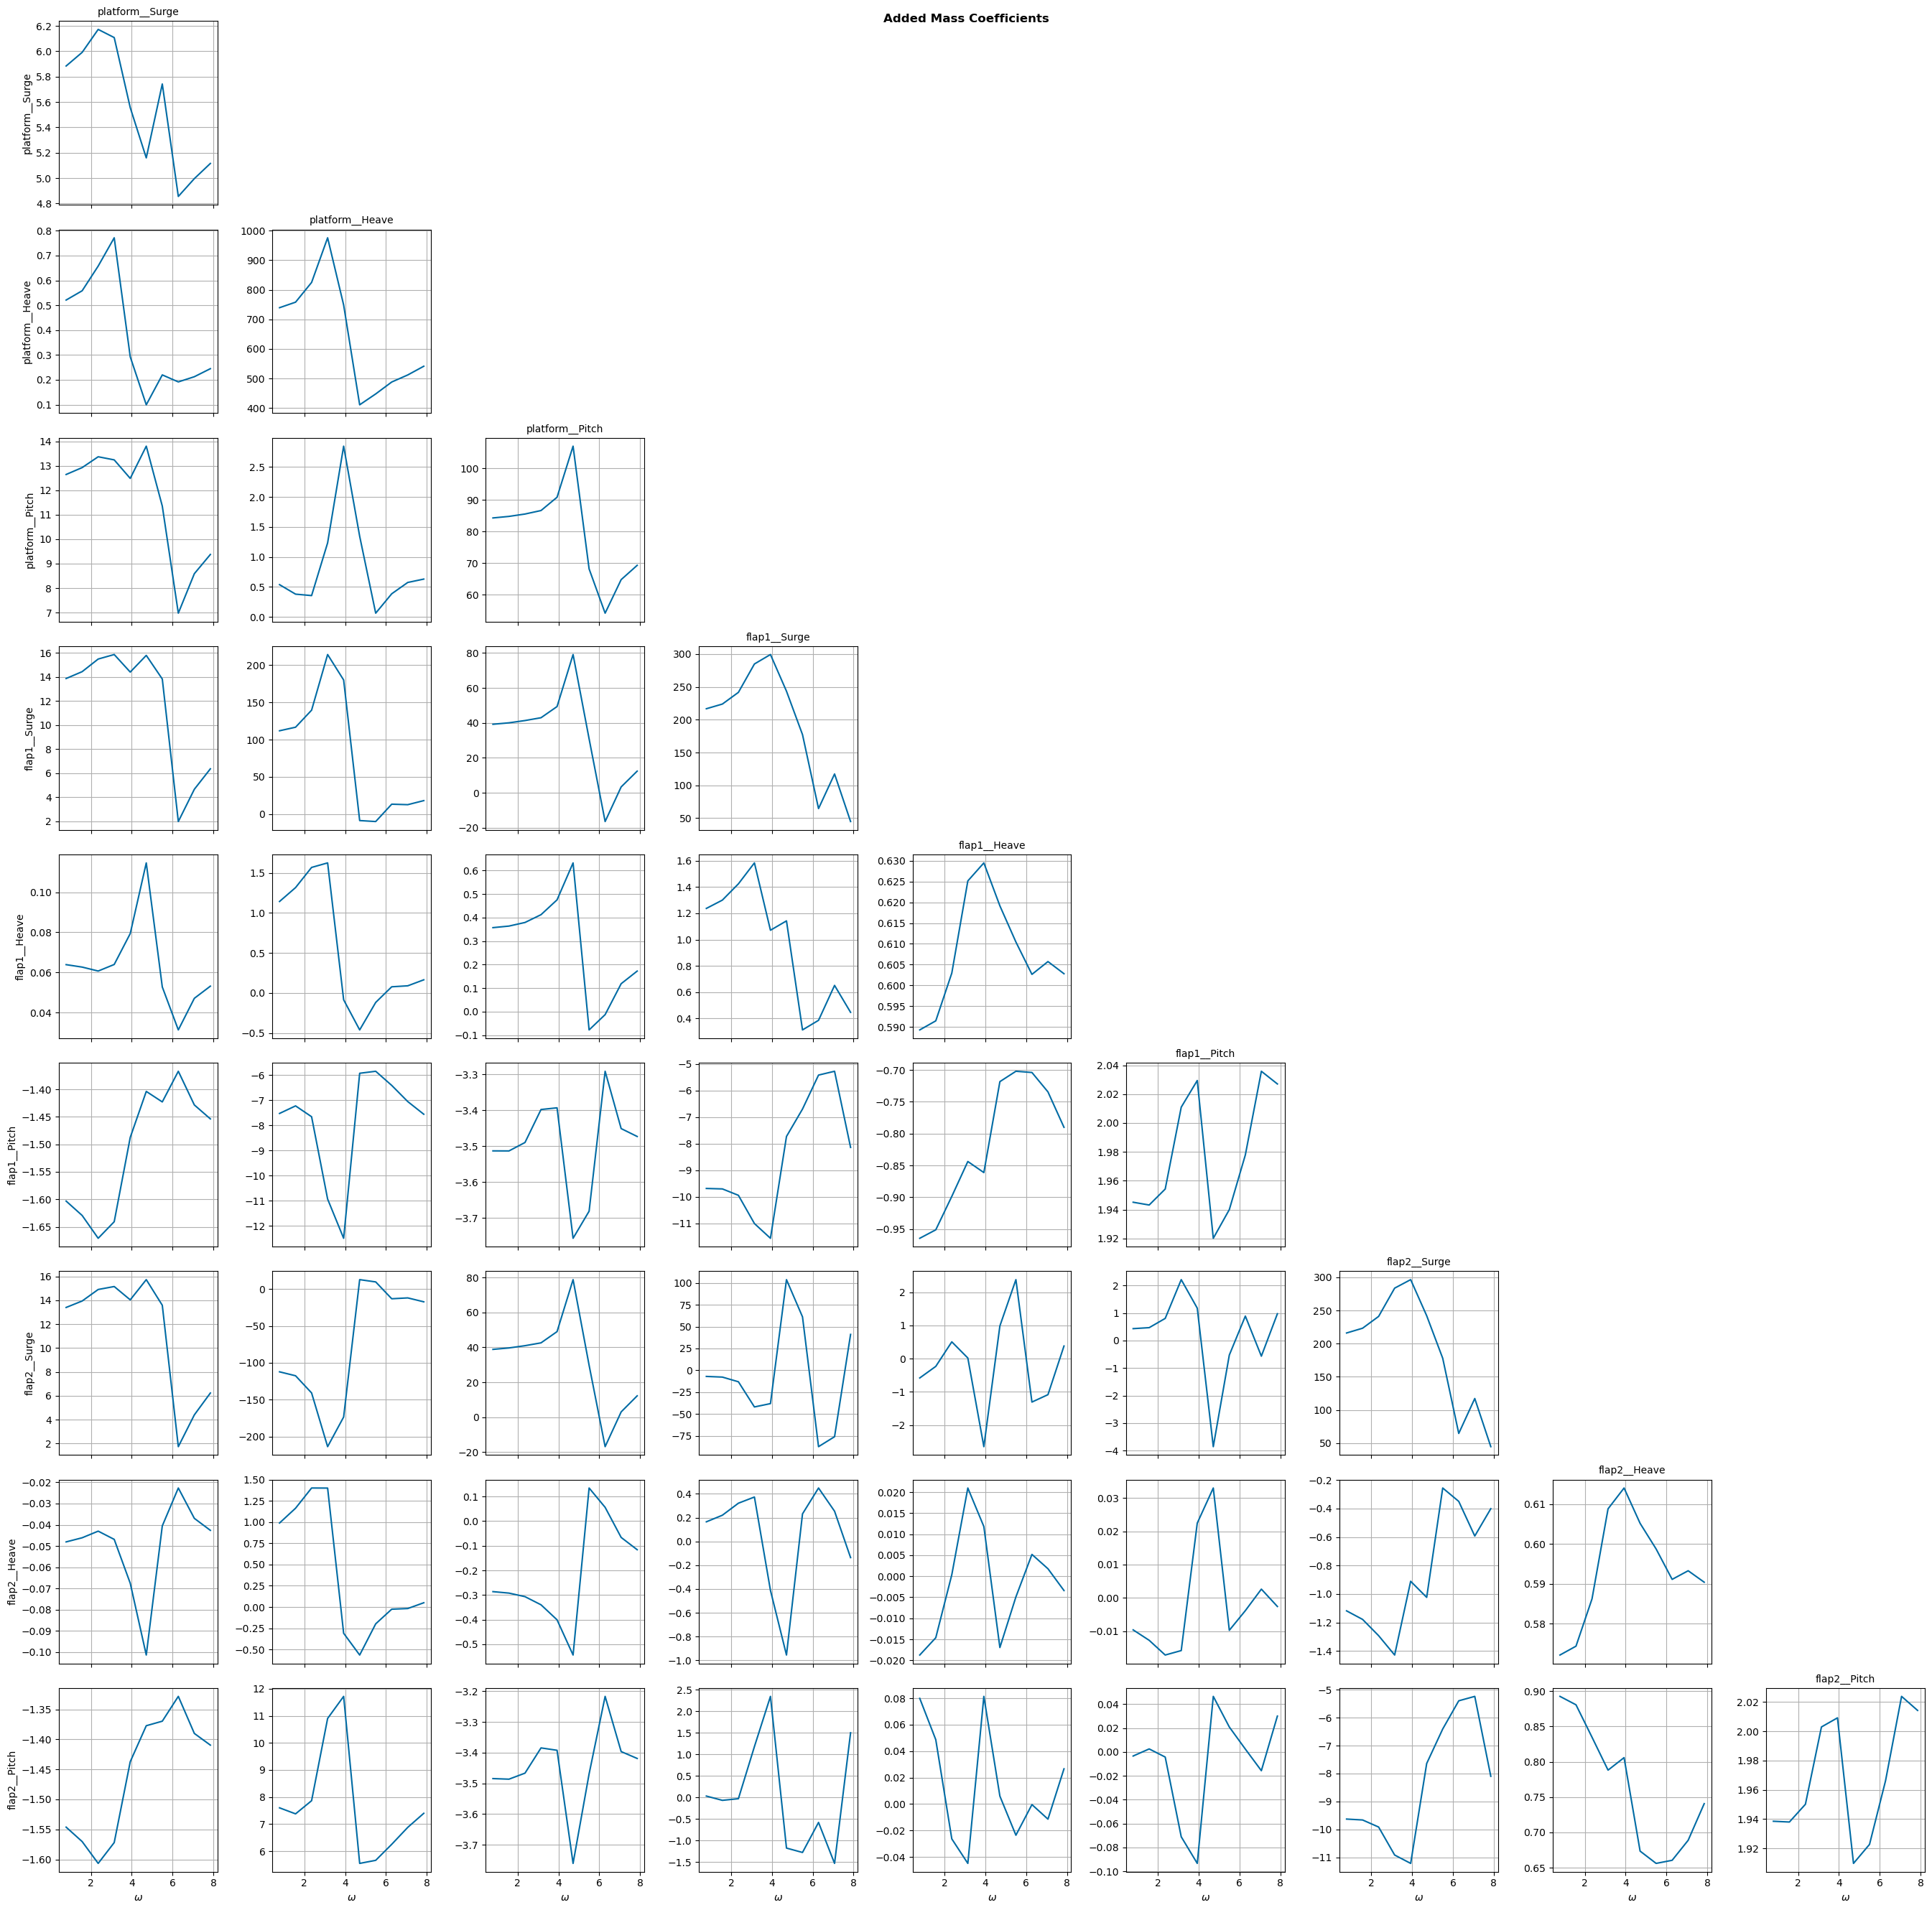

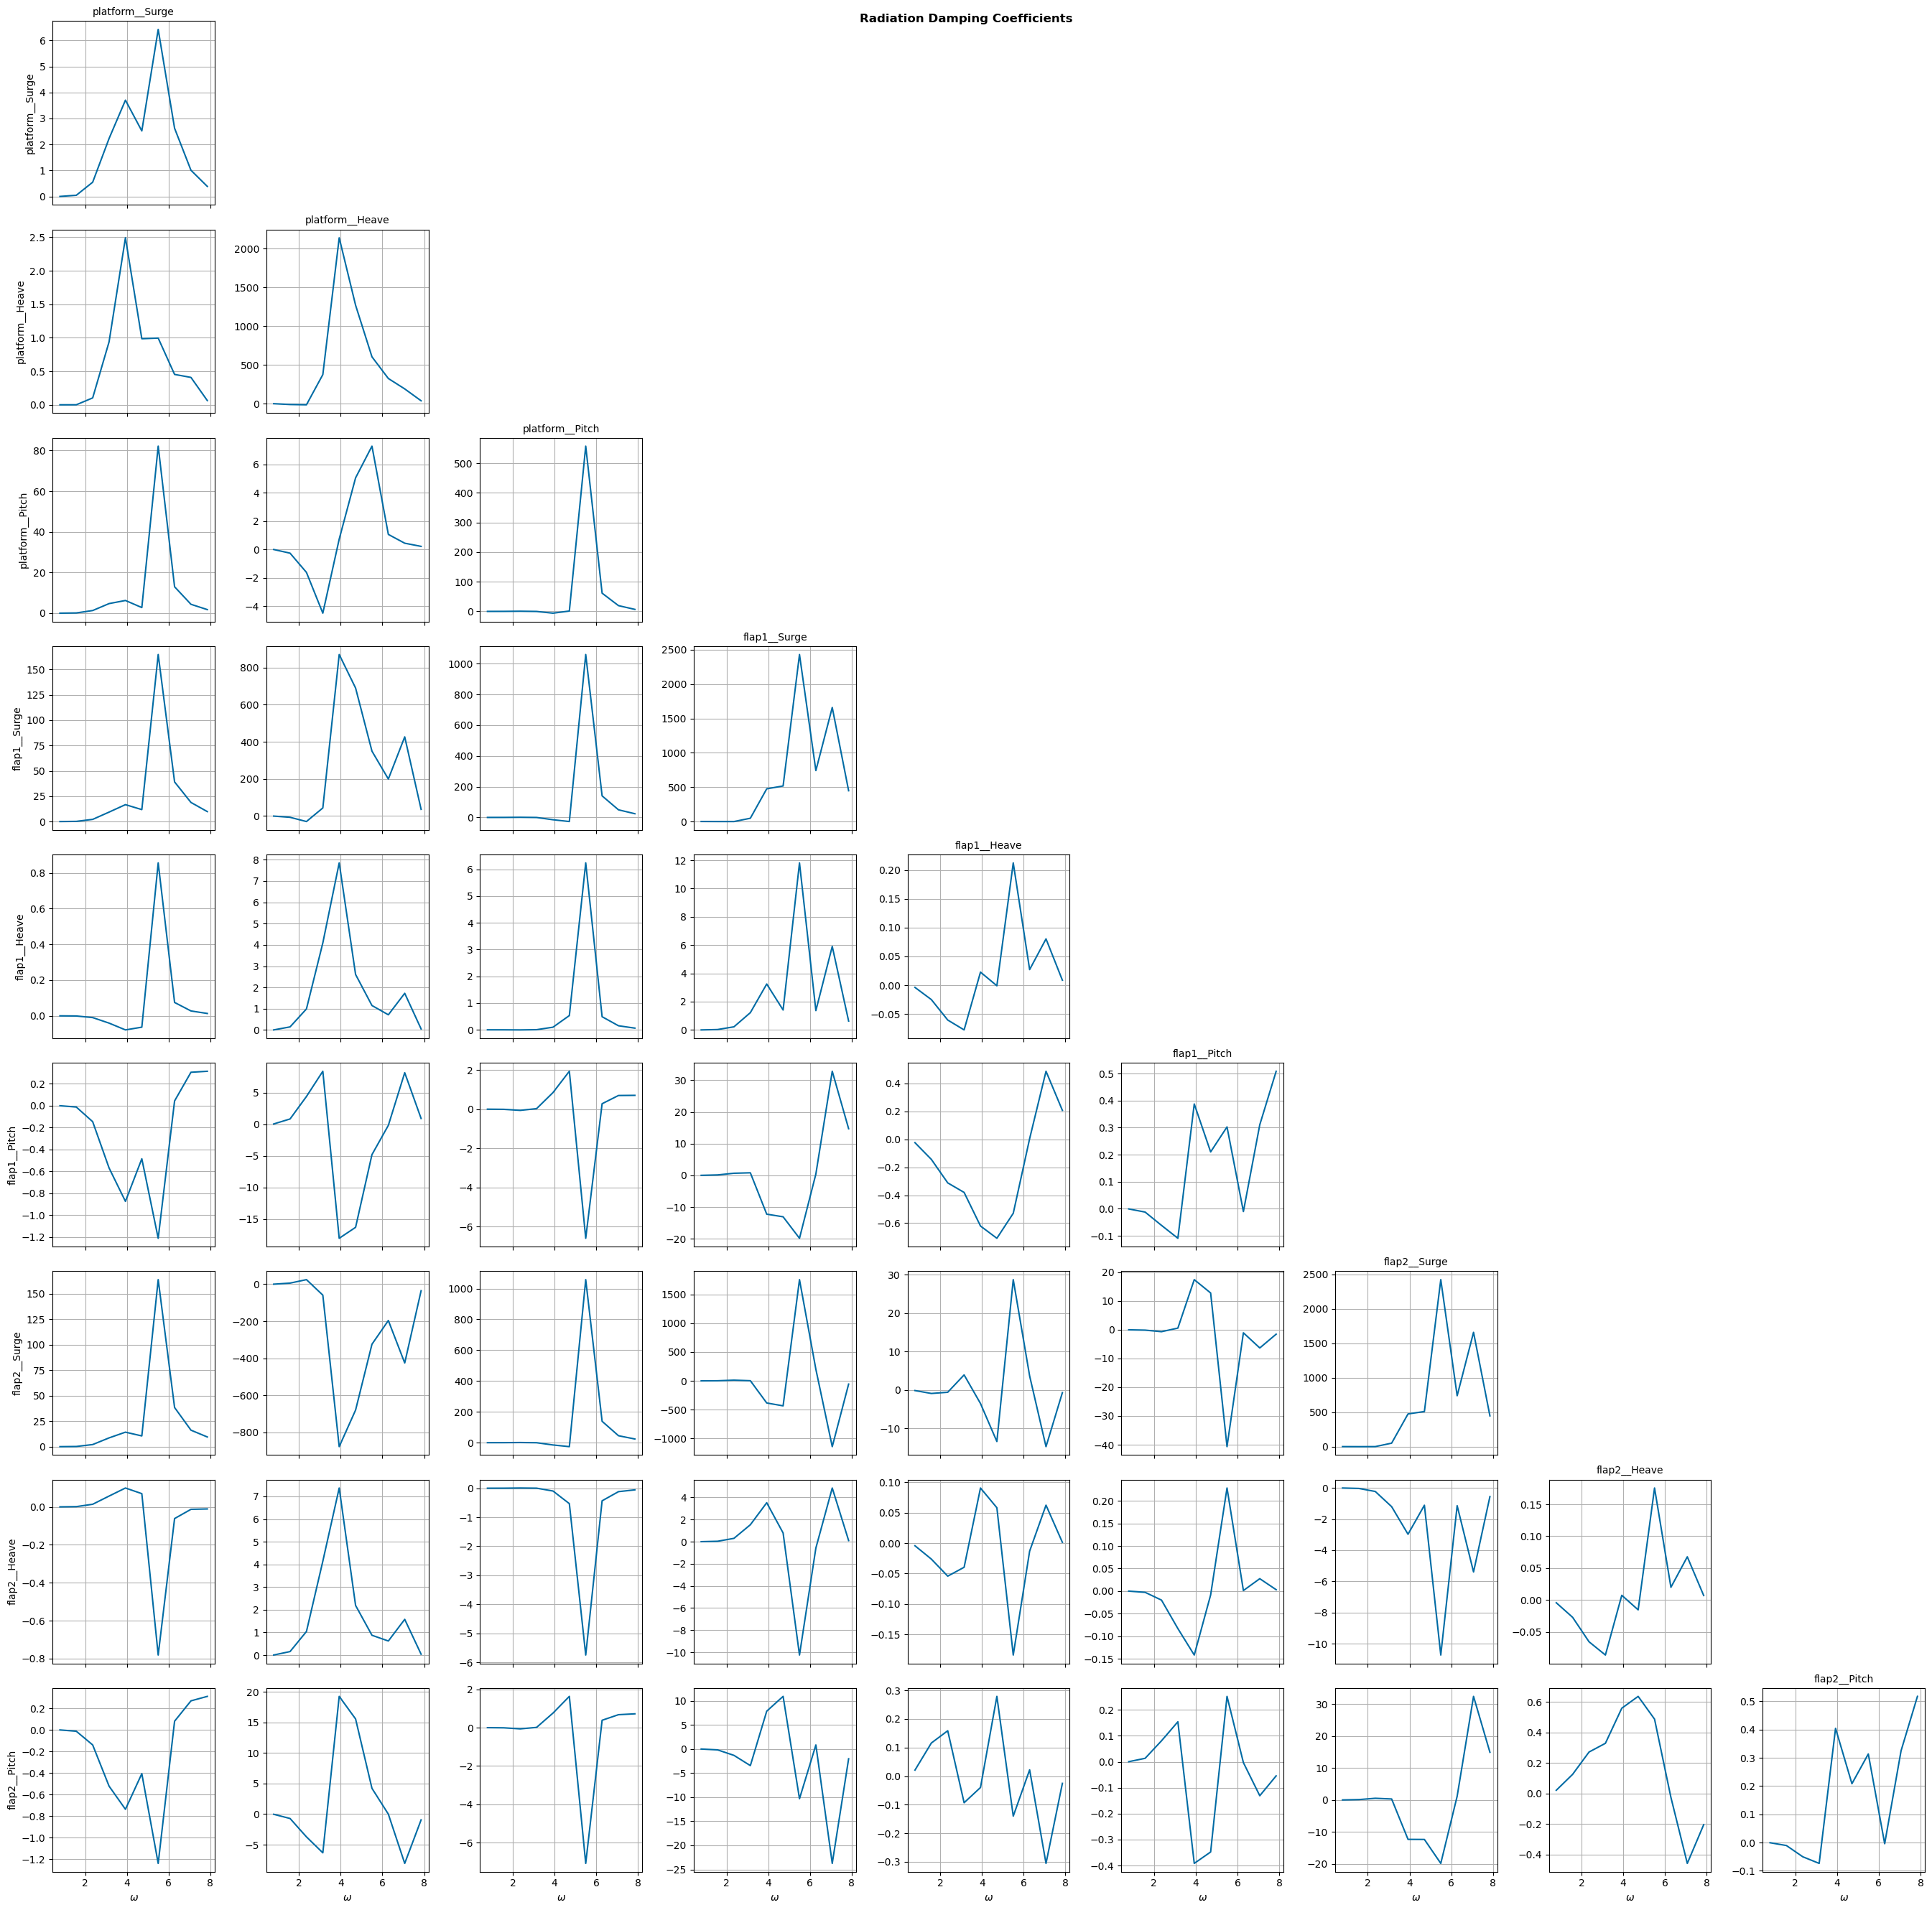

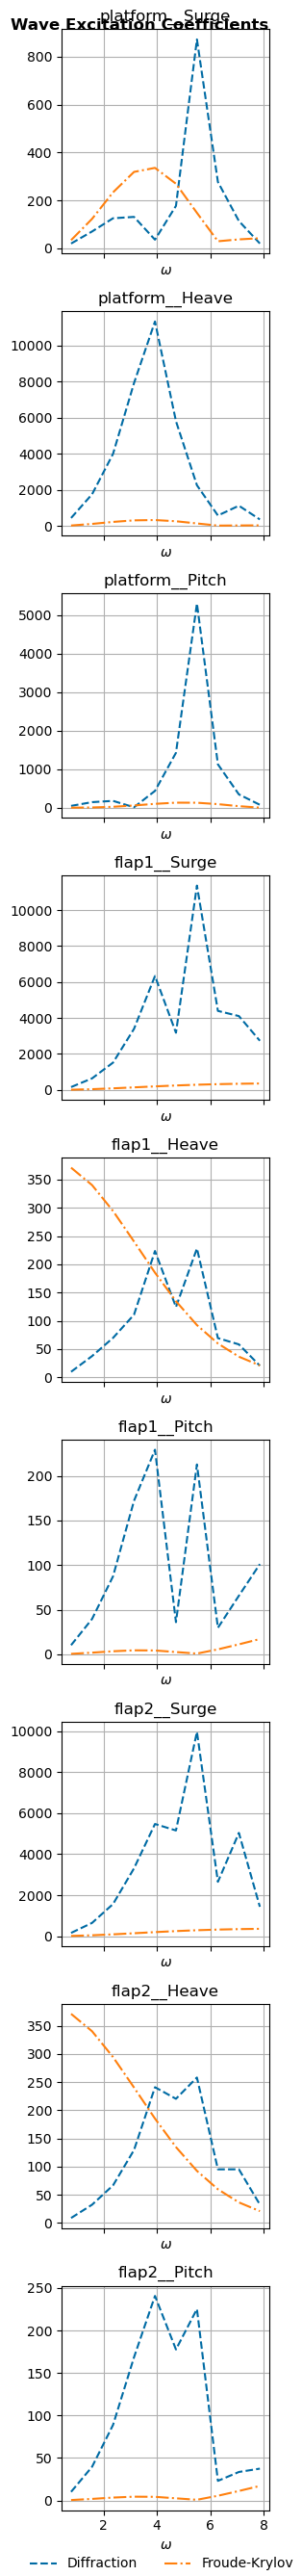

In [75]:
bem_data_plot = bem_data.sel(wave_direction = 0, method='nearest')
radiating_dofs = bem_data_plot.radiating_dof.values
influenced_dofs = bem_data_plot.influenced_dof.values

# plots
fig_am, ax_am = plt.subplots(
    len(radiating_dofs), 
    len(influenced_dofs),
    tight_layout=True, 
    sharex=True, 
    figsize=(3*len(radiating_dofs),3*len(influenced_dofs)),
    squeeze=False
    )
fig_rd, ax_rd = plt.subplots(
    len(radiating_dofs),
    len(influenced_dofs),
    tight_layout=True,
    sharex=True, 
    figsize=(3*len(radiating_dofs), 3*len(influenced_dofs)),
    squeeze=False
    )
fig_ex, ax_ex = plt.subplots(
    len(influenced_dofs),
    1,
    tight_layout=True, 
    sharex=True, 
    figsize=(3, 3*len(radiating_dofs)), 
    squeeze=False
    )
[ax.grid(True) for axs in (ax_am, ax_rd, ax_ex) for ax in axs.flatten()]
# plot titles
fig_am.suptitle('Added Mass Coefficients', fontweight='bold')
fig_rd.suptitle('Radiation Damping Coefficients', fontweight='bold')
fig_ex.suptitle('Wave Excitation Coefficients', fontweight='bold')

sp_idx = 0
for i, rdof in enumerate(radiating_dofs):
    for j, idof in enumerate(influenced_dofs):
        sp_idx += 1
        if i == 0:
            np.abs(bem_data_plot.diffraction_force.sel(influenced_dof=idof)).plot(
                ax=ax_ex[j,0], linestyle='dashed', label='Diffraction')
            np.abs(bem_data_plot.Froude_Krylov_force.sel(influenced_dof=idof)).plot(
                ax=ax_ex[j,0], linestyle='dashdot', label='Froude-Krylov')
            ex_handles, ex_labels = ax_ex[j,0].get_legend_handles_labels()
            ax_ex[j,0].set_title(f'{idof}')
            ax_ex[j,0].set_xlabel('')
            ax_ex[j,0].set_ylabel('')
        if j <= i:
            bem_data_plot.added_mass.sel(
                radiating_dof=rdof, influenced_dof=idof).plot(ax=ax_am[i, j])
            bem_data_plot.radiation_damping.sel(
                radiating_dof=rdof, influenced_dof=idof).plot(ax=ax_rd[i, j])
            if i == len(radiating_dofs)-1:
                ax_am[i, j].set_xlabel(f'$\omega$', fontsize=10)
                ax_rd[i, j].set_xlabel(f'$\omega$', fontsize=10)
                ax_ex[j, 0].set_xlabel(f'$\omega$', fontsize=10)
            else:
                ax_am[i, j].set_xlabel('')
                ax_rd[i, j].set_xlabel('')
            if j == 0:
                ax_am[i, j].set_ylabel(f'{rdof}', fontsize=10)
                ax_rd[i, j].set_ylabel(f'{rdof}', fontsize=10)
            else:
                ax_am[i, j].set_ylabel('')
                ax_rd[i, j].set_ylabel('')
            if j == i:
                ax_am[i, j].set_title(f'{idof}', fontsize=10)
                ax_rd[i, j].set_title(f'{idof}', fontsize=10)
            else:
                ax_am[i, j].set_title('')
                ax_rd[i, j].set_title('')
        else:
            fig_am.delaxes(ax_am[i, j])
            fig_rd.delaxes(ax_rd[i, j])
fig_ex.legend(ex_handles, ex_labels, loc=(0.08, 0), ncol=2, frameon=False)

Problem initialization finished in:		 0.002 seconds
All branches in the graph:
Branch 1: [1, 2]
Branch 2: [1, 3]


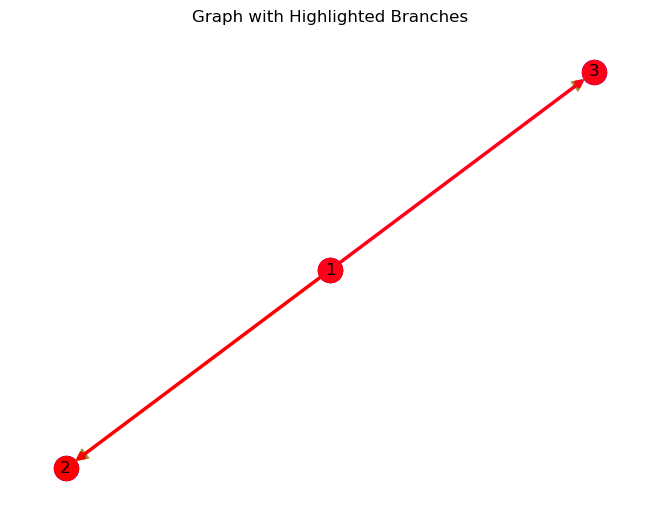

R and RD matrices calculation finished in:	 0.276 seconds
Symbolic EOM computation finished in:		 0.009 seconds
Compiling EOM expressions finished in:		 0.234 seconds
Original Rotation Matrix (R):
[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [1.00000000000000 0 0.72*sin(Theta_1) 0.17*cos(Theta_2) 0]
 [0 1.00000000000000 0.72*cos(Theta_1) -0.17*sin(Theta_2) 0]
 [0 0 0 1 0]
 [1.00000000000000 0 -0.72*sin(Theta_1) 0 0.17*cos(Theta_3)]
 [0 1.00000000000000 -0.72*cos(Theta_1) 0 -0.17*sin(Theta_3)]
 [0 0 0 0 1]]
Substituted Rotation Matrix (R_subs):
[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [1.00000000000000 0 0 0.170000000000000 0]
 [0 1.00000000000000 0.720000000000000 0 0]
 [0 0 0 1 0]
 [1.00000000000000 0 0 0 0.170000000000000]
 [0 1.00000000000000 -0.720000000000000 0 0]
 [0 0 0 0 1]]


In [76]:
import multibody as mb
import sympy
import m4e_foswec

MBDsys = mb.MBDSystem.from_example(m4e_foswec)

# Print the original rotation matrix
print("Original Rotation Matrix (R):")
print(np.array(MBDsys.R))

# Create a mapping of symbols to values based on their names
value_mapping = {
    'Theta_1': 0,
    'Theta_2': 0,
    'Theta_3': 0,
}

substitution_dict = {symbol: value_mapping[str(symbol)] for symbol in list(MBDsys.R.free_symbols) if str(symbol) in value_mapping}
R_subs = MBDsys.R.subs(substitution_dict)
print("Substituted Rotation Matrix (R_subs):")
print(np.array(R_subs))


In [77]:
# Verify that mass matrix is equivalent using MBCsys and R
# Print the original rotation matrix
#print("Original Mass Matrix (ReducedM):")
#print(np.array(MBDsys.ReducedM))

# Create a mapping of symbols to values based on their names
value_mapping = {
    'm1': platform.inertia_matrix[0,0].values,
    'm2': flap1.inertia_matrix[0,0].values,
    'm3': flap2.inertia_matrix[0,0].values,
    'J1': platform.inertia_matrix[2,2].values,
    'J2': flap1.inertia_matrix[2,2].values,
    'J3': flap2.inertia_matrix[2,2].values,
    'Theta_1': 0,
    'Theta_2': 0,
    'Theta_3': 0,
}

substitution_dict = {symbol: value_mapping[str(symbol)] for symbol in list(MBDsys.ReducedM.free_symbols) if str(symbol) in value_mapping}
ReducedM_subs = MBDsys.ReducedM.subs(substitution_dict)
#print("Substituted Mass Matrix (ReducedM_subs):")
#print(np.array(ReducedM_subs))

mass_matrix = block_diag(platform.inertia_matrix.values,flap1.inertia_matrix.values,flap2.inertia_matrix.values)

reduced_mass_matrix = np.array(R_subs,dtype=np.complex128).T @ mass_matrix @ np.array(R_subs,dtype=np.complex128)

#print("Check Mass Matrix (ReducedM_subs):")
#print(reduced_mass_matrix) # Matches!!

In [78]:
print(MBDsys.R)
print(np.array(R_subs))
print(np.array(R_subs).T)

Matrix([[1, 0, 0, 0, 0], [0, 1, 0, 0, 0], [0, 0, 1, 0, 0], [1.00000000000000, 0, 0.72*sin(Theta_1), 0.17*cos(Theta_2), 0], [0, 1.00000000000000, 0.72*cos(Theta_1), -0.17*sin(Theta_2), 0], [0, 0, 0, 1, 0], [1.00000000000000, 0, -0.72*sin(Theta_1), 0, 0.17*cos(Theta_3)], [0, 1.00000000000000, -0.72*cos(Theta_1), 0, -0.17*sin(Theta_3)], [0, 0, 0, 0, 1]])
[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [1.00000000000000 0 0 0.170000000000000 0]
 [0 1.00000000000000 0.720000000000000 0 0]
 [0 0 0 1 0]
 [1.00000000000000 0 0 0 0.170000000000000]
 [0 1.00000000000000 -0.720000000000000 0 0]
 [0 0 0 0 1]]
[[1 0 0 1.00000000000000 0 0 1.00000000000000 0 0]
 [0 1 0 0 1.00000000000000 0 0 1.00000000000000 0]
 [0 0 1 0 0.720000000000000 0 0 -0.720000000000000 0]
 [0 0 0 0.170000000000000 0 1 0 0 0]
 [0 0 0 0 0 0 0.170000000000000 0 1]]


In [79]:
added_mass = np.squeeze(bem_data['added_mass'].data) # Added mass
radiation_damping = np.squeeze(bem_data['radiation_damping'].data)  # Radiation damping
hydrostatic_stiffness = np.squeeze(bem_data['hydrostatic_stiffness'].data)  # Hydrostatic stiffness
excitation_force = np.squeeze(bem_data['excitation_force'].data) # Excitation force

omega = freq*2*np.pi
impedance_matrix = (mass_matrix + added_mass)*1j*omega[:, np.newaxis, np.newaxis] + radiation_damping - (1j/omega[:, np.newaxis, np.newaxis])*np.repeat(hydrostatic_stiffness[np.newaxis, :, :], 10, axis=0)
impedance_reduced = np.array(R_subs,dtype=np.complex128).T @ impedance_matrix @ np.array(R_subs,dtype=np.complex128)
print(np.shape(impedance_reduced))

hydrostatic_stiffness_reduced = (np.array(R_subs,dtype=np.complex128).T @ hydrostatic_stiffness @ np.array(R_subs,dtype=np.complex128))
print(np.shape(hydrostatic_stiffness_reduced))

excitation_reduced = np.squeeze(bem_data['excitation_force'].values @ np.array(R_subs,dtype=np.complex128))[:,np.newaxis,:]

wave_direction = np.array([wavedir,])
nwave_direction = len(wave_direction)
coords_exc = {
    'omega': (['omega'], omega, {'units': 'rad/s'}),
    'wave_direction': (['wave_direction'], wave_direction, {'units': 'rad'}),
    'influenced_dof': (['influenced_dof'], ['surge_platform', 'heave_platform','pitch_platform','pitch_flap1','pitch_flap2'], {}),
}
excitation_reduced = xr.DataArray(excitation_reduced, coords=coords_exc, attrs={})

print(np.shape(excitation_reduced))

(10, 5, 5)
(5, 5)
(10, 1, 5)


In [80]:
# add forces to stabilize system

mooring_stiffness = [1e4, 1e5, 1e6, 0, 0, 0, 0, 0, 0]
mooring_stiffness = mooring_stiffness @ np.array(R_subs,dtype=np.float64)
mooring_damping = [1e3, 1e4, 1e5, 0, 0, 0, 0, 0, 0]
mooring_damping = mooring_damping @ np.array(R_subs,dtype=np.float64)

def f_mooring(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat,pos)
 
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)
    mooring = pos*mooring_stiffness + vel*mooring_damping
    #print(mooring)
    mooring_force = jnp.dot(time_matrix,mooring)
    #print(mooring_force)
    return mooring_force

# add prentension 
def f_pretension(wec, x_wec, x_opt, wave, nsubsteps=1):
    pretension = np.zeros((20,5))
    pretension[:,1] = -9.81*2*(1-0.2)*(flapThickness*platformWidth*-platformCG[2])*1000
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)
    pretension_force = jnp.dot(time_matrix,pretension)
    return pretension_force
# WecOptTool does not take gravity into account and assumes equilibrium so no pretension needed?

f_add = {'mooring': f_mooring}

In [81]:
wec = wot.WEC.from_impedance(
    freq,
    impedance=impedance_reduced,
    exc_coeff=excitation_reduced,
    hydrostatic_stiffness=hydrostatic_stiffness_reduced,
    constraints=None,
    f_add=f_add,
)

# Objective function
obj_fun = lambda wec, x_wec, x_opt, waves : 0
nstate_opt = 0

# Solve
scale_x_wec = 1e1
scale_x_opt = 1e-3
scale_obj = 1e-2

results = wec.solve(
    waves,
    obj_fun,
    nstate_opt,
    scale_x_wec=scale_x_wec,
    scale_x_opt=scale_x_opt,
    scale_obj=scale_obj,
)


[09:58:18] WARNING  Real part of impedance for 1 has negative or close to zero terms. Shifting up elements [1 2] to
                    a minimum of  1e-06 N/(m/s)

           WARNING  Real part of impedance for 2 has negative or close to zero terms. Shifting up elements [4] to a
                    minimum of  1e-06 N/(m/s)

           WARNING  Real part of impedance for 3 has negative or close to zero terms. Shifting up elements [0 1] to
                    a minimum of  1e-06 N/(m/s)

           WARNING  Real part of impedance for 4 has negative or close to zero terms. Shifting up elements [0 1] to
                    a minimum of  1e-06 N/(m/s)

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [7.80e+00, nan, 0.00e+00]
INFO:wecopttool.core:Optimization terminated successfully    (Exit mode 0)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 2
            Gradient evaluations: 1


c:\Users\jtgrasb\AppData\Local\anaconda3\envs\wot_dev\Lib\site-packages\wecopttool\core.py:967: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'omega' ('omega',) The recommendation is to set join explicitly for this case.
  results_fd = xr.merge([fd_state, fd_forces, wave])
c:\Users\jtgrasb\AppData\Local\anaconda3\envs\wot_dev\Lib\site-packages\wecopttool\core.py:967: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  results_fd 

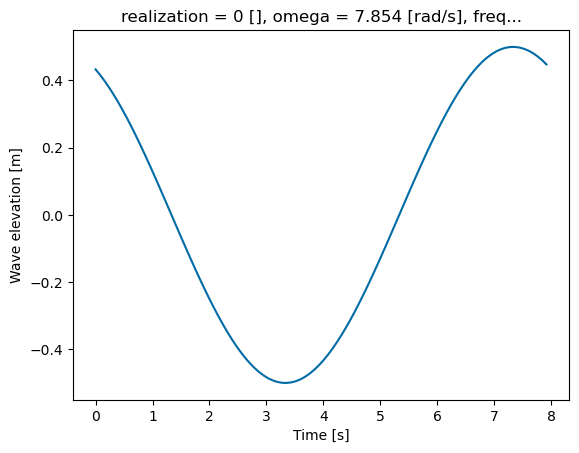

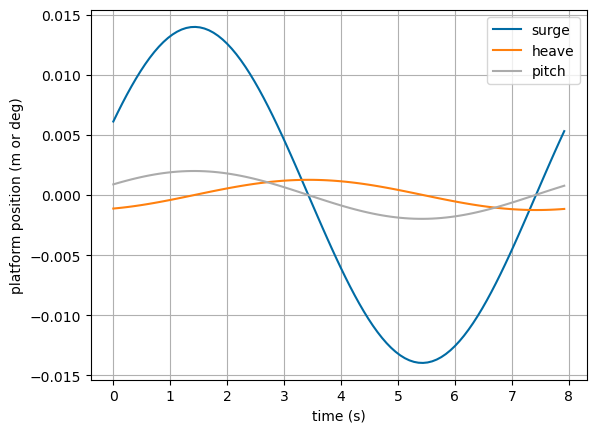

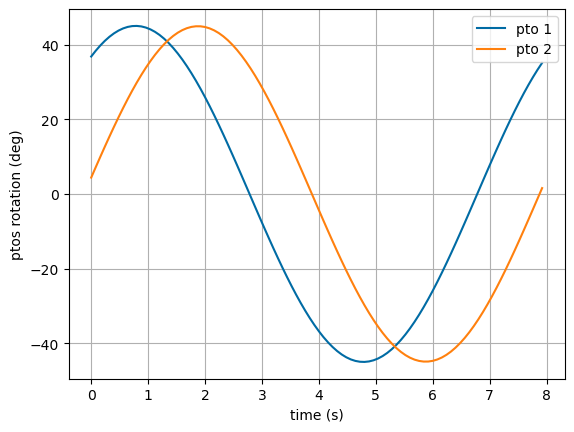

In [82]:
nsubsteps = 5
wec_fdom, wec_tdom = wec.post_process(wec, results, waves, nsubsteps=nsubsteps)

wec_tdom['wave_elev'].plot()

plt.figure()
plt.plot(wec_tdom['time'],wec_tdom.pos[0,0,:])
plt.plot(wec_tdom['time'],wec_tdom.pos[0,1,:])
plt.plot(wec_tdom['time'],wec_tdom.pos[0,2,:]*180/np.pi)
plt.xlabel('time (s)')
plt.ylabel('platform position (m or deg)')
plt.legend(['surge','heave','pitch'])
plt.grid()


plt.figure()
plt.plot(wec_tdom['time'],wec_tdom.pos[0,3,:]*180/np.pi)
plt.plot(wec_tdom['time'],wec_tdom.pos[0,4,:]*180/np.pi)
plt.xlabel('time (s)')
plt.ylabel('ptos rotation (deg)')
plt.legend(['pto 1', 'pto 2'])
plt.grid()